In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import ast
from random import expovariate

# Driver

In [16]:
df_driver = pd.read_excel("drivers.xlsx")
df_driver.head()

,id,arrival_time,offline_time,initial_location,current_location,status,arrival_datetime,offline_datetime
0,1,5.011975,11.638223,"(0.7897740952818868, 8.194226996886005)","(13.492895938215721, 17.375090044074234)",offline,2025-12-01 13:00:43.110,2025-12-01 19:38:17.601
1,2,5.557763,11.732854,"(4.600342938200451, 13.82151625336585)","(13.6809497478333, 15.070060581064372)",offline-scheduled,2025-12-01 13:33:27.947,2025-12-01 19:43:58.273
2,3,5.661047,12.723458,"(9.09829206926925, 11.669336718393772)","(15.86922281798255, 9.936190354974855)",offline-scheduled,2025-12-01 13:39:39.768,2025-12-01 20:43:24.450
3,4,5.757413,12.793147,"(14.723720219958555, 14.743429470057318)","(14.232702333916698, 12.939560071816741)",offline-scheduled,2025-12-01 13:45:26.686,2025-12-01 20:47:35.330
4,5,5.769205,12.431118,"(13.023825947458846, 12.501871643860605)","(19.845683334071563, 7.3885004325174215)",offline-scheduled,2025-12-01 13:46:09.139,2025-12-01 20:25:52.025


Average inter-arrival time: 0.2108701912804591


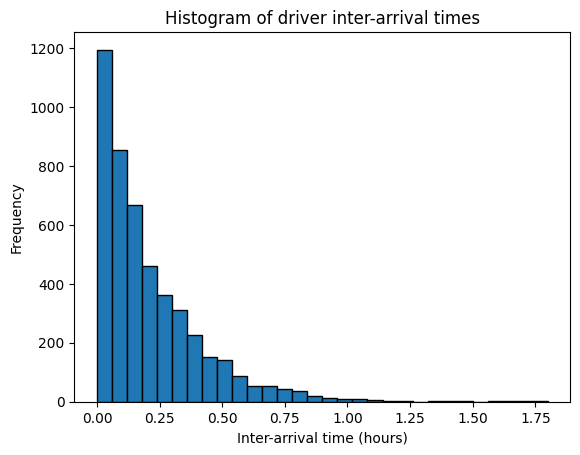

In [17]:
# Sort drivers by their arrival time
df_sorted = df_driver.sort_values(by="arrival_time")

# Compute the time differences between consecutive arrivals
df_sorted["inter_arrival"] = df_sorted["arrival_time"].diff()

# Remove the first row since it has no previous arrival to compare with
inter_arrivals = df_sorted["inter_arrival"].dropna()

# Print the average inter-arrival time
print("Average inter-arrival time:", inter_arrivals.mean())

# Plot a histogram of inter-arrival times
plt.hist(inter_arrivals, bins=30, edgecolor='black')
plt.xlabel("Inter-arrival time (hours)")
plt.ylabel("Frequency")
plt.title("Histogram of driver inter-arrival times")
plt.show()


Based on the driver dataset the empirical inter arrival times follow an exponential like shape consistent with BoxCar’s assumption. However, the mean inter arrival time is 0.2108 hours (12.6 minutes) which is significantly lower than the assumed 1/3 hours (20 minutes). This indicates that drivers arrive more frequently in reality than suggested by the model and therefore the simulation should use a higher arrival rate than 
3 driver per hour

Minimum shift length: 6.000735775974306
Maximum shift length: 7.999785397523965
Average shift length: 7.004658336500881


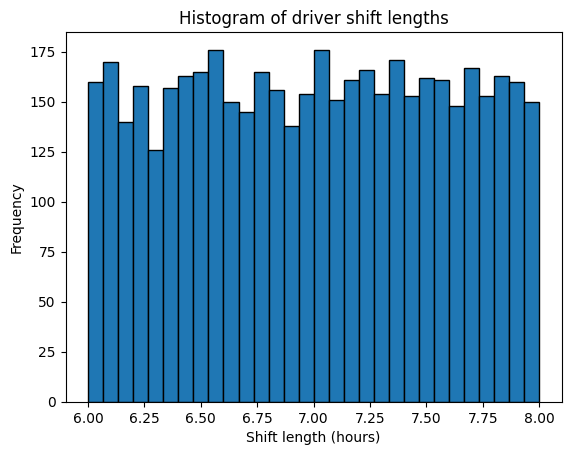

In [18]:
# Calculate each driver's shift length (time online)
df_driver["shift_length"] = df_driver["offline_time"] - df_driver["arrival_time"]

# Print basic statistics about shift lengths
print("Minimum shift length:", df_driver["shift_length"].min())
print("Maximum shift length:", df_driver["shift_length"].max())
print("Average shift length:", df_driver["shift_length"].mean())

# Plot a histogram of shift lengths
plt.hist(df_driver["shift_length"], bins=30, edgecolor='black')
plt.xlabel("Shift length (hours)")
plt.ylabel("Frequency")
plt.title("Histogram of driver shift lengths")
plt.show()

In [19]:
# Display the proportion of each status category
print(df_driver["status"].value_counts(normalize=True))

status
offline-scheduled    0.552024
offline              0.439288
busy                 0.004450
available            0.004238
Name: proportion, dtype: float64


The status distribution shows that 55.2% of drivers end their shift through a scheduled offline event, while 43.9% go offline unexpectedly. Only 0.44% are busy and 0.42% are available at the snapshot time. This indicates that most drivers follow a scheduled shift ending pattern but a significant portion (nearly 44%) disconnect unexpectedly which should be considered when modeling driver availability in the simulation

# Rider

In [20]:
df_rider = pd.read_excel("riders.xlsx") 
df_rider.head()

,id,request_time,pickup_time,dropoff_time,pickup_location,dropoff_location,status,request_datetime,pickup_datetime,dropoff_datetime
0,1,5.048803,5.372603,5.668817,"(8.52776815255513, 11.374422951736026)","(11.22406718305943, 18.28586415472845)",dropped-off,2025-12-01 13:02:55.690,2025-12-01 13:22:21.370,2025-12-01 13:40:07.743
1,2,5.113495,5.344117,5.658663,"(4.7260253234018075, 13.921168220313202)","(11.219433016467919, 9.224932723238288)",dropped-off,2025-12-01 13:06:48.580,2025-12-01 13:20:38.822,2025-12-01 13:39:31.187
2,3,5.114319,5.819045,6.154474,"(9.34931432850313, 14.855954034601385)","(15.818906976292498, 14.556629597532137)",dropped-off,2025-12-01 13:06:51.547,2025-12-01 13:49:08.563,2025-12-01 14:09:16.107
3,4,5.210384,5.492225,5.915581,"(5.341657715440439, 9.121586876730834)","(11.832789025965816, 11.90864135355879)",dropped-off,2025-12-01 13:12:37.383,2025-12-01 13:29:32.010,2025-12-01 13:54:56.092
4,5,5.229512,5.421566,6.019653,"(5.444067188695589, 13.774420071355813)","(11.208517457838962, 5.792638826367501)",dropped-off,2025-12-01 13:13:46.244,2025-12-01 13:25:17.639,2025-12-01 14:01:10.751


Average rider inter-arrival time: 0.028904982877070474


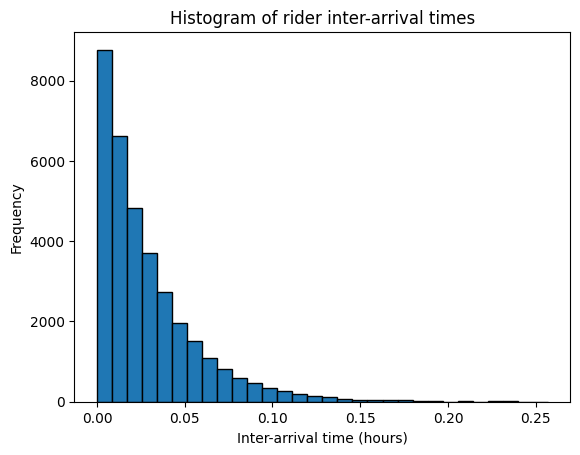

In [21]:
# Sort riders by request time
df_sorted = df_rider.sort_values(by="request_time")

# Compute inter-arrival times
df_sorted["inter_arrival"] = df_sorted["request_time"].diff()

# Remove first NaN
inter_arrivals = df_sorted["inter_arrival"].dropna()

print("Average rider inter-arrival time:", inter_arrivals.mean())

# Plot histogram
plt.hist(inter_arrivals, bins=30, edgecolor='black')
plt.xlabel("Inter-arrival time (hours)")
plt.ylabel("Frequency")
plt.title("Histogram of rider inter-arrival times")
plt.show()

The empirical rider inter arrival times follow an exponential like distribution consistent with BoxCar’s assumption. However, the mean inter arrival time is 0.0289 hours (1.7 minutes) corresponding to an arrival rate of approximately 34.6 riders per hour. This indicates that rider demand is very high and should be modeled using a significantly higher arrival rate in the simulation

Average waiting time: 0.23669790966719373


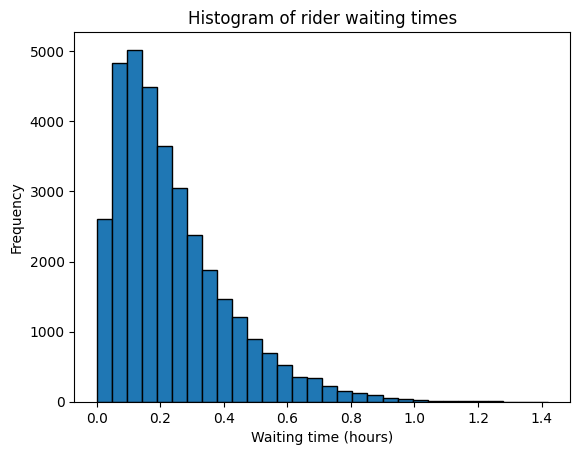

In [22]:
# Keep only valid rows where pickup happens after request
df_rider = df_rider[df_rider["pickup_time"] >= df_rider["request_time"]]

# Compute waiting time
df_rider["waiting_time"] = df_rider["pickup_time"] - df_rider["request_time"]

# Print average waiting time
print("Average waiting time:", df_rider["waiting_time"].mean())

# Plot histogram
plt.hist(df_rider["waiting_time"], bins=30, edgecolor='black')
plt.xlabel("Waiting time (hours)")
plt.ylabel("Frequency")
plt.title("Histogram of rider waiting times")
plt.show()

After removing invalid records where pickup_time occurred before request_time the empirical waiting times show a right skewed distribution with an average of 0.2367 hours (14 minutes). Most riders experience short waiting times, but a minority wait significantly longer creating a long tail. This pattern is typical in high‑demand systems and should be reflected in the simulation model

Average trip duration: 0.40865107533110434


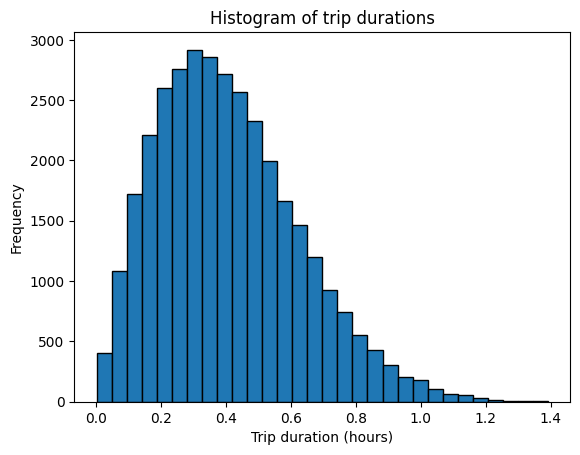

In [23]:
# Keep only valid rows where dropoff happens after pickup
df_rider = df_rider[df_rider["dropoff_time"] >= df_rider["pickup_time"]]

# Compute trip duration
df_rider["trip_duration"] = df_rider["dropoff_time"] - df_rider["pickup_time"]

# Print average trip duration
print("Average trip duration:", df_rider["trip_duration"].mean())

# Plot histogram
plt.hist(df_rider["trip_duration"], bins=30, edgecolor='black')
plt.xlabel("Trip duration (hours)")
plt.ylabel("Frequency")
plt.title("Histogram of trip durations")
plt.show()

After removing invalid records where dropoff_time occurred before pickup_time the empirical trip durations show a right skewed distribution with an average of 0.4086 hours (24.5 minutes). Most trips are relatively short but a minority of longer trips create a long tail. This pattern is typical in real transportation systems and should be reflected in the simulation model

In [24]:
print(df_rider["status"].value_counts(normalize=True))

status
dropped-off          0.999502
dropoff-scheduled    0.000498
Name: proportion, dtype: float64


The rider status distribution shows that 99.95% of riders were successfully dropped off while only 0.05% were in a dropoff‑scheduled state. No riders were abandoned or cancelled. This indicates that the system is operating with very high service reliability and rider demand is being met effectively

Average trip distance (miles): 8.162759193253956


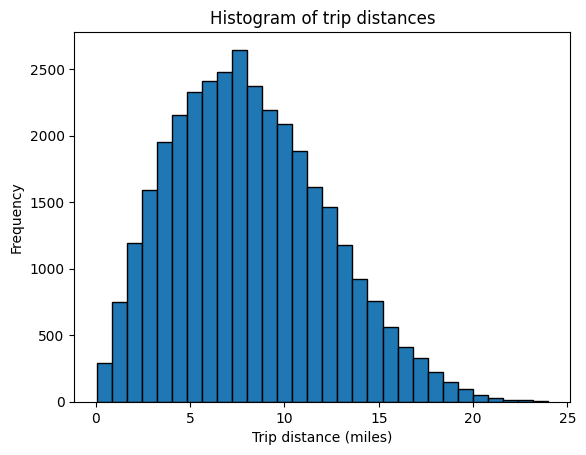

In [27]:
import ast
from math import sqrt

# Function to convert "(x, y)" text into numeric tuple
def parse_point(s):
    x, y = ast.literal_eval(s)
    return x, y

# Extract coordinates
pickup_x, pickup_y = zip(*df_rider["pickup_location"].map(parse_point))
drop_x, drop_y = zip(*df_rider["dropoff_location"].map(parse_point))

# Compute Euclidean distance
df_rider["trip_distance"] = [
    sqrt((dx - px)**2 + (dy - py)**2)
    for px, py, dx, dy in zip(pickup_x, pickup_y, drop_x, drop_y)
]

# Print average distance
print("Average trip distance (miles):", df_rider["trip_distance"].mean())

# Plot histogram
plt.hist(df_rider["trip_distance"], bins=30, edgecolor='black')
plt.xlabel("Trip distance (miles)")
plt.ylabel("Frequency")
plt.title("Histogram of trip distances")
plt.show()

The empirical trip distances show a right skewed distribution with an average of 8.16 miles. Most trips fall between 5 and 12 miles which is consistent with random origin destination pairs within a 20×20 mile region. This validates the spatial assumptions of the BoxCar model

# Simulation

In [ ]:
# -----------------------------
# 1) Event list + scheduling tools
# -----------------------------
event_list = []

def schedule_event(event_type, time, data=None):
    event = {"type": event_type, "time": time, "data": data}
    heapq.heappush(event_list, (time, event))

def get_next_event(event_list):
    time, event = heapq.heappop(event_list)
    return event


# -----------------------------
# 2) Rider arrival handler
# -----------------------------

def handle_rider_arrival(event):
    global simulation_clock

    rider = {
        "arrival_time": event["time"],
        "origin": (random.uniform(0, 20), random.uniform(0, 20)),
        "destination": (random.uniform(0, 20), random.uniform(0, 20)),
        "status": "waiting"
    }

    riders_waiting.append(rider)

    next_time = simulation_clock + expovariate(lambda_rider)
    schedule_event("RIDER_ARRIVAL", time=next_time)

    schedule_event("MATCH", time=simulation_clock)


# -----------------------------
# 3) Driver arrival handler
# -----------------------------

def handle_driver_arrival(event):
    global simulation_clock

    driver = {
        "arrival_time": event["time"],
        "location": (random.uniform(0, 20), random.uniform(0, 20)),
        "status": "idle",
        "earnings": 0
    }

    drivers.append(driver)

    next_time = simulation_clock + expovariate(lambda_driver)
    schedule_event("DRIVER_ARRIVAL", time=next_time)

    schedule_event("MATCH", time=simulation_clock)


# -----------------------------
# 4) Matching handler
# -----------------------------

def distance(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def handle_matching(event):
    global simulation_clock

    if len(riders_waiting) == 0 or len(drivers) == 0:
        return

    rider = riders_waiting.pop(0)

    # Find the closest driver to this rider (using rider origin)
    closest_driver = min(drivers, key=lambda d: distance(d["location"], rider["origin"]))

    rider["status"] = "matched"
    closest_driver["status"] = "busy"

    schedule_event("PICKUP", time=simulation_clock, data={"rider": rider, "driver": closest_driver})


# -----------------------------
# 5) Initialize simulation
# -----------------------------

simulation_clock = 0

drivers = []
riders_waiting = []

metrics = {
    "waiting_times": [],
    "abandonments": 0,
    "driver_earnings": {},
}

lambda_rider = 34.6
lambda_driver = 3

SIMULATION_END = 24


# -----------------------------
# 6) Pickup handler (ETA)
# -----------------------------

def handle_pickup(event):
    global simulation_clock

    rider = event["data"]["rider"]
    driver = event["data"]["driver"]

    # Compute distance between driver and rider
    d = distance(driver["location"], rider["origin"])

    # Expected travel time
    mu_t = d / 20

    # Actual ETA
    eta = random.uniform(0.8 * mu_t, 1.2 * mu_t)

    schedule_event(
        "PICKUP_COMPLETE",
        time=simulation_clock + eta,
        data={"rider": rider, "driver": driver}
    )


schedule_event("RIDER_ARRIVAL", time=expovariate(lambda_rider))
schedule_event("DRIVER_ARRIVAL", time=expovariate(lambda_driver))


# -----------------------------
# 7) Pickup complete handler (Trip time)
# -----------------------------

def handle_pickup_complete(event):
    global simulation_clock

    rider = event["data"]["rider"]
    driver = event["data"]["driver"]

    d_trip = distance(rider["origin"], rider["destination"])

    mu_trip = d_trip / 20

    trip_time = random.uniform(0.8 * mu_trip, 1.2 * mu_trip)

    schedule_event(
        "DROPOFF",
        time=simulation_clock + trip_time,
        data={"rider": rider, "driver": driver, "trip_distance": d_trip}
    )


# -----------------------------
# 8) Dropoff handler (Fare + Fuel + Earnings)
# -----------------------------

def handle_dropoff(event):
    global simulation_clock

    rider = event["data"]["rider"]
    driver = event["data"]["driver"]
    d_trip = event["data"]["trip_distance"]

    # 1) Compute trip cost
    fare = 3 + 2 * d_trip     # £3 base + £2 per mile

    # 2) Compute fuel cost
    fuel_cost = 0.20 * d_trip     # £0.20 per mile

    # 3) Update driver earnings
    net_earning = fare - fuel_cost
    driver["earnings"] += net_earning

    # After dropping off the rider, the driver moves to the rider's destination.
    # This update is essential so that future matching uses the correct driver location.
    driver["location"] = rider["destination"]

    # 4) Driver becomes idle
    driver["status"] = "idle"

    # 5) Try to match this driver with the next waiting rider
    schedule_event("MATCH", time=simulation_clock)
    
    
    # Save earnings in metrics
    metrics["driver_earnings"][id(driver)] = driver["earnings"]

# -----------------------------
# 9) Driver offline handler
# -----------------------------

def handle_driver_offline(event):
    driver = event["data"]["driver"]

    if driver in drivers:
        drivers.remove(driver)

    driver["status"] = "offline"


# -----------------------------
# 10) Main simulation loop
# -----------------------------

while simulation_clock < SIMULATION_END:

    event = get_next_event(event_list)
    simulation_clock = event["time"]

    if event["type"] == "RIDER_ARRIVAL":
        handle_rider_arrival(event)

    elif event["type"] == "DRIVER_ARRIVAL":
        handle_driver_arrival(event)

    elif event["type"] == "MATCH":
        handle_matching(event)

    elif event["type"] == "PICKUP":
        handle_pickup(event)

    elif event["type"] == "PICKUP_COMPLETE":
        handle_pickup_complete(event)

    elif event["type"] == "DROPOFF":
        handle_dropoff(event)

    elif event["type"] == "DRIVER_GO_OFFLINE":
        handle_driver_offline(event)


# -----------------------------
# 11) Print final results
# -----------------------------

def print_results(metrics):

    if len(metrics["waiting_times"]) > 0:
        avg_wait = sum(metrics["waiting_times"]) / len(metrics["waiting_times"])
    else:
        avg_wait = 0

    print("----- Simulation Results -----")
    print(f"Average waiting time: {avg_wait:.2f} hours")
    print(f"Total abandonments: {metrics['abandonments']}")

    print("\nDriver earnings:")
    for driver in drivers:
        print(f"Driver {id(driver)}: {driver['earnings']:.2f} units")


print_results(metrics)

----- Simulation Results -----
Average waiting time: 0.00 hours
Total abandonments: 0

Driver earnings:
Driver 1726670244480: 1005.88 units
Driver 1726645319744: 1264.86 units
Driver 1726670766592: 741.87 units
Driver 1726645309888: 813.38 units
Driver 1726646950976: 923.49 units
Driver 1728688989632: 908.39 units
Driver 1726644211776: 700.34 units
Driver 1726626147008: 570.58 units
Driver 1726644078464: 318.02 units
Driver 1726625702656: 537.30 units
Driver 1726644223168: 579.58 units
Driver 1726644083328: 414.54 units
Driver 1726646959040: 596.43 units
Driver 1726645211008: 286.45 units
Driver 1726644087872: 357.74 units
Driver 1728688039040: 199.77 units
Driver 1726644208256: 260.96 units
Driver 1726644539072: 434.12 units
Driver 1726626140096: 246.29 units
Driver 1726625698688: 408.81 units
Driver 1726646949376: 305.96 units
Driver 1726644921600: 431.39 units
Driver 1726626140032: 285.49 units
Driver 1726644550336: 143.10 units
Driver 1726670252672: 200.48 units
Driver 172868689395

In [70]:
#The number of drivers who worked
print(len(metrics["driver_earnings"]))

59
